Adjusting p-values for 234 contrasts separately...
Median significant genes per contrast: 1
Range: 0-3862
Adjusting 10,689,808 p-values globally...
Globally significant tests: 98,660 / 10,689,808 (0.9%)

Comparison of adjustment methods:
              total_significant  median_per_contrast  median_per_gene  \
per_cellline            98660.0                 13.0              3.0   
per_contrast           156766.0                  1.0              7.0   
global                  98660.0                 13.0              3.0   

              max_per_contrast  max_per_gene  
per_cellline            2127.0         207.0  
per_contrast            3862.0         183.0  
global                  2127.0         207.0  


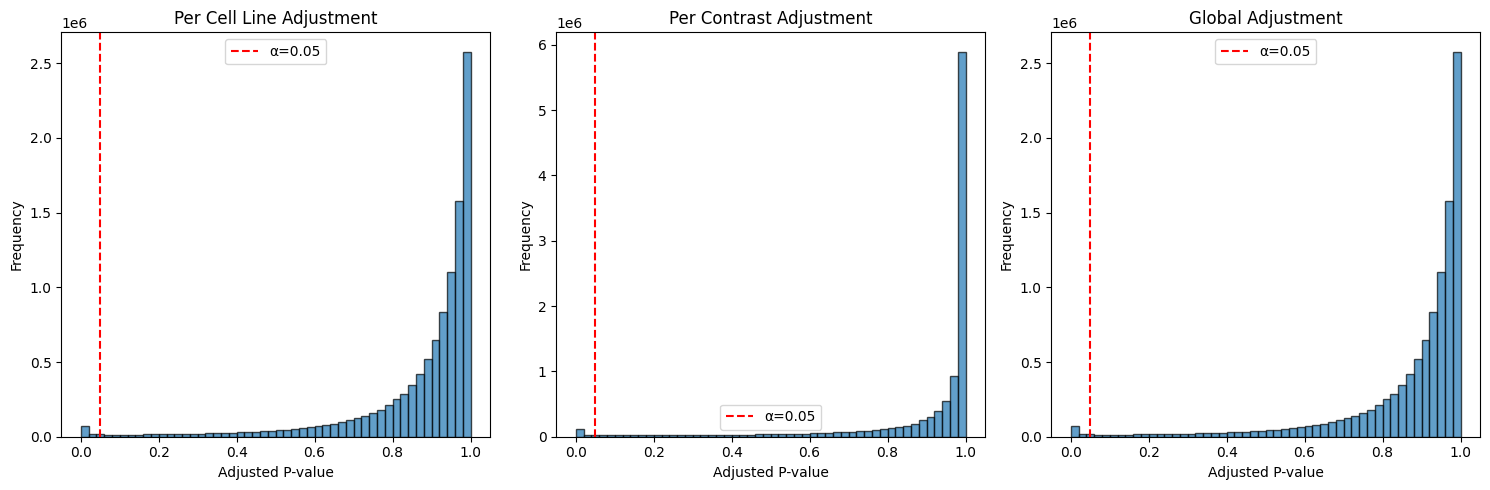

In [ ]:
import anndata as ad
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

def adjust_pvalues_per_contrast(adata, grouping_cols=['cell_line', 'perturbation', 'time']):
    """
    Adjust p-values separately for each contrast (most conservative approach).
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with P.Value layer
    grouping_cols : list
        Columns that define a unique contrast
        
    Returns:
    --------
    AnnData object with new layer 'per_contrast_adj.P.Value'
    """
    # Extract p-values matrix
    pvals = adata.layers['P.Value'].copy()
    
    # Initialize adjusted p-values matrix
    adj_pvals = np.full_like(pvals, np.nan)
    
    # Create grouping key
    adata.obs['contrast_key'] = adata.obs[grouping_cols].astype(str).agg('_'.join, axis=1)
    
    # Get unique contrasts
    unique_contrasts = adata.obs['contrast_key'].unique()
    
    print(f"Adjusting p-values for {len(unique_contrasts)} contrasts separately...")
    
    # Adjust p-values for each contrast independently
    for contrast in unique_contrasts:
        # Get indices for this contrast
        mask = adata.obs['contrast_key'] == contrast
        contrast_idx = np.where(mask)[0]
        
        if len(contrast_idx) == 0:
            continue
            
        # For each contrast (row), adjust p-values across all genes
        for idx in contrast_idx:
            # Get p-values for this contrast
            contrast_pvals = pvals[idx, :]
            
            # Handle NaN values
            valid_mask = ~np.isnan(contrast_pvals)
            
            if np.sum(valid_mask) > 0:
                # Adjust only non-NaN p-values
                _, adj_p, _, _ = multipletests(
                    contrast_pvals[valid_mask], 
                    method='fdr_bh', 
                    is_sorted=False
                )
                
                # Put adjusted p-values back
                adj_pvals[idx, valid_mask] = adj_p
    
    # Add as new layer
    adata.layers['per_contrast_adj.P.Value'] = adj_pvals
    
    # Clean up temporary column
    adata.obs.drop('contrast_key', axis=1, inplace=True)
    
    # Report statistics
    n_sig_per_contrast = np.sum(adj_pvals < 0.05, axis=1)
    print(f"Median significant genes per contrast: {np.median(n_sig_per_contrast):.0f}")
    print(f"Range: {np.min(n_sig_per_contrast)}-{np.max(n_sig_per_contrast)}")
    
    return adata


def adjust_pvalues_globally(adata):
    """
    Adjust p-values globally across entire experiment.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with P.Value layer
        
    Returns:
    --------
    AnnData object with new layer 'global_adj.P.Value'
    """
    # Extract p-values matrix
    pvals = adata.layers['P.Value'].copy()
    
    # Flatten to 1D array for global adjustment
    pvals_flat = pvals.flatten()
    
    # Handle NaN values
    valid_mask = ~np.isnan(pvals_flat)
    
    print(f"Adjusting {np.sum(valid_mask):,} p-values globally...")
    
    # Initialize adjusted p-values
    adj_pvals_flat = np.full_like(pvals_flat, np.nan)
    
    if np.sum(valid_mask) > 0:
        # Adjust all valid p-values together
        _, adj_p, _, _ = multipletests(
            pvals_flat[valid_mask], 
            method='fdr_bh', 
            is_sorted=False
        )
        
        # Put adjusted p-values back
        adj_pvals_flat[valid_mask] = adj_p
    
    # Reshape back to original matrix shape
    adj_pvals = adj_pvals_flat.reshape(pvals.shape)
    
    # Add as new layer
    adata.layers['global_adj.P.Value'] = adj_pvals
    
    # Report statistics
    n_sig_global = np.sum(adj_pvals < 0.05)
    n_total = np.sum(valid_mask)
    print(f"Globally significant tests: {n_sig_global:,} / {n_total:,} ({n_sig_global/n_total*100:.1f}%)")
    
    return adata


def compare_adjustment_methods(adata, gene_names=None):
    """
    Compare the three p-value adjustment methods.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with all three adjustment layers
    gene_names : list, optional
        Specific genes to examine
        
    Returns:
    --------
    DataFrame with comparison statistics
    """
    methods = {
        'per_cellline': 'per_cellline_adj.P.Value',
        'per_contrast': 'per_contrast_adj.P.Value', 
        'global': 'global_adj.P.Value'
    }
    
    # Count significant results for each method
    results = {}
    for method_name, layer_name in methods.items():
        if layer_name in adata.layers:
            sig_matrix = adata.layers[layer_name] < 0.05
            results[method_name] = {
                'total_significant': np.sum(sig_matrix),
                'median_per_contrast': np.median(np.sum(sig_matrix, axis=1)),
                'median_per_gene': np.median(np.sum(sig_matrix, axis=0)),
                'max_per_contrast': np.max(np.sum(sig_matrix, axis=1)),
                'max_per_gene': np.max(np.sum(sig_matrix, axis=0))
            }
    
    comparison_df = pd.DataFrame(results).T
    
    print("\nComparison of adjustment methods:")
    print(comparison_df)
    
    # If specific genes provided, show their results
    if gene_names is not None and 'ensembl_id' in adata.var.columns:
        gene_mask = adata.var['ensembl_id'].isin(gene_names)
        gene_indices = np.where(gene_mask)[0]
        
        if len(gene_indices) > 0:
            print(f"\nResults for specified genes:")
            for gene_idx in gene_indices:
                gene_id = adata.var.iloc[gene_idx]['ensembl_id']
                print(f"\nGene: {gene_id}")
                for method_name, layer_name in methods.items():
                    if layer_name in adata.layers:
                        n_sig = np.sum(adata.layers[layer_name][:, gene_idx] < 0.05)
                        print(f"  {method_name}: {n_sig} significant contrasts")
    
    return comparison_df

de_results = ad.read_h5ad("../../data/processed/sciplex/deg/A549_de.h5ad")
de_results.layers['per_cellline_adj.P.Value'] = de_results.layers['adj.P.Value']
del de_results.layers['adj.P.Value']

adata = adjust_pvalues_per_contrast(de_results)

adata = adjust_pvalues_globally(adata)

comparison = compare_adjustment_methods(adata)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (method, layer) in enumerate([
    ('Per Cell Line', 'per_cellline_adj.P.Value'),
    ('Per Contrast', 'per_contrast_adj.P.Value'),
    ('Global', 'global_adj.P.Value')
]):
    if layer in adata.layers:
        pvals = adata.layers[layer].flatten()
        pvals = pvals[~np.isnan(pvals)]
        
        axes[i].hist(pvals, bins=50, alpha=0.7, edgecolor='black')
        axes[i].axvline(x=0.05, color='red', linestyle='--', label='α=0.05')
        axes[i].set_xlabel('Adjusted P-value')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{method} Adjustment')
        axes[i].legend()

plt.tight_layout()
plt.show()

    

In [12]:
adata.write_h5ad("../../data/processed/sciplex/deg/A549_de_adjusted.h5ad", compression="gzip")

Loading DE results for all cell lines...
Loading A549 from ../../data/processed/sciplex/deg/A549_de.h5ad
  Shape: 919 contrasts × 11632 genes
  Applying per-contrast adjustment for A549...
  Adjusting p-values for 919 contrasts (row-by-row) ...
    Median significant genes per contrast: 1
    Range: 0–3862
Loading K562 from ../../data/processed/sciplex/deg/K562_de.h5ad
  Shape: 732 contrasts × 10992 genes
  Applying per-contrast adjustment for K562...
  Adjusting p-values for 732 contrasts (row-by-row) ...
    Median significant genes per contrast: 1
    Range: 0–1824
Loading MCF7 from ../../data/processed/sciplex/deg/MCF7_de.h5ad
  Shape: 744 contrasts × 16308 genes
  Applying per-contrast adjustment for MCF7...
  Adjusting p-values for 744 contrasts (row-by-row) ...
    Median significant genes per contrast: 2
    Range: 0–7803

Successfully loaded 3 cell lines

APPLYING GLOBAL ADJUSTMENT ACROSS ALL CELL LINES

Total non-NaN p-values to adjust globally: 30,869,104
Performing global F

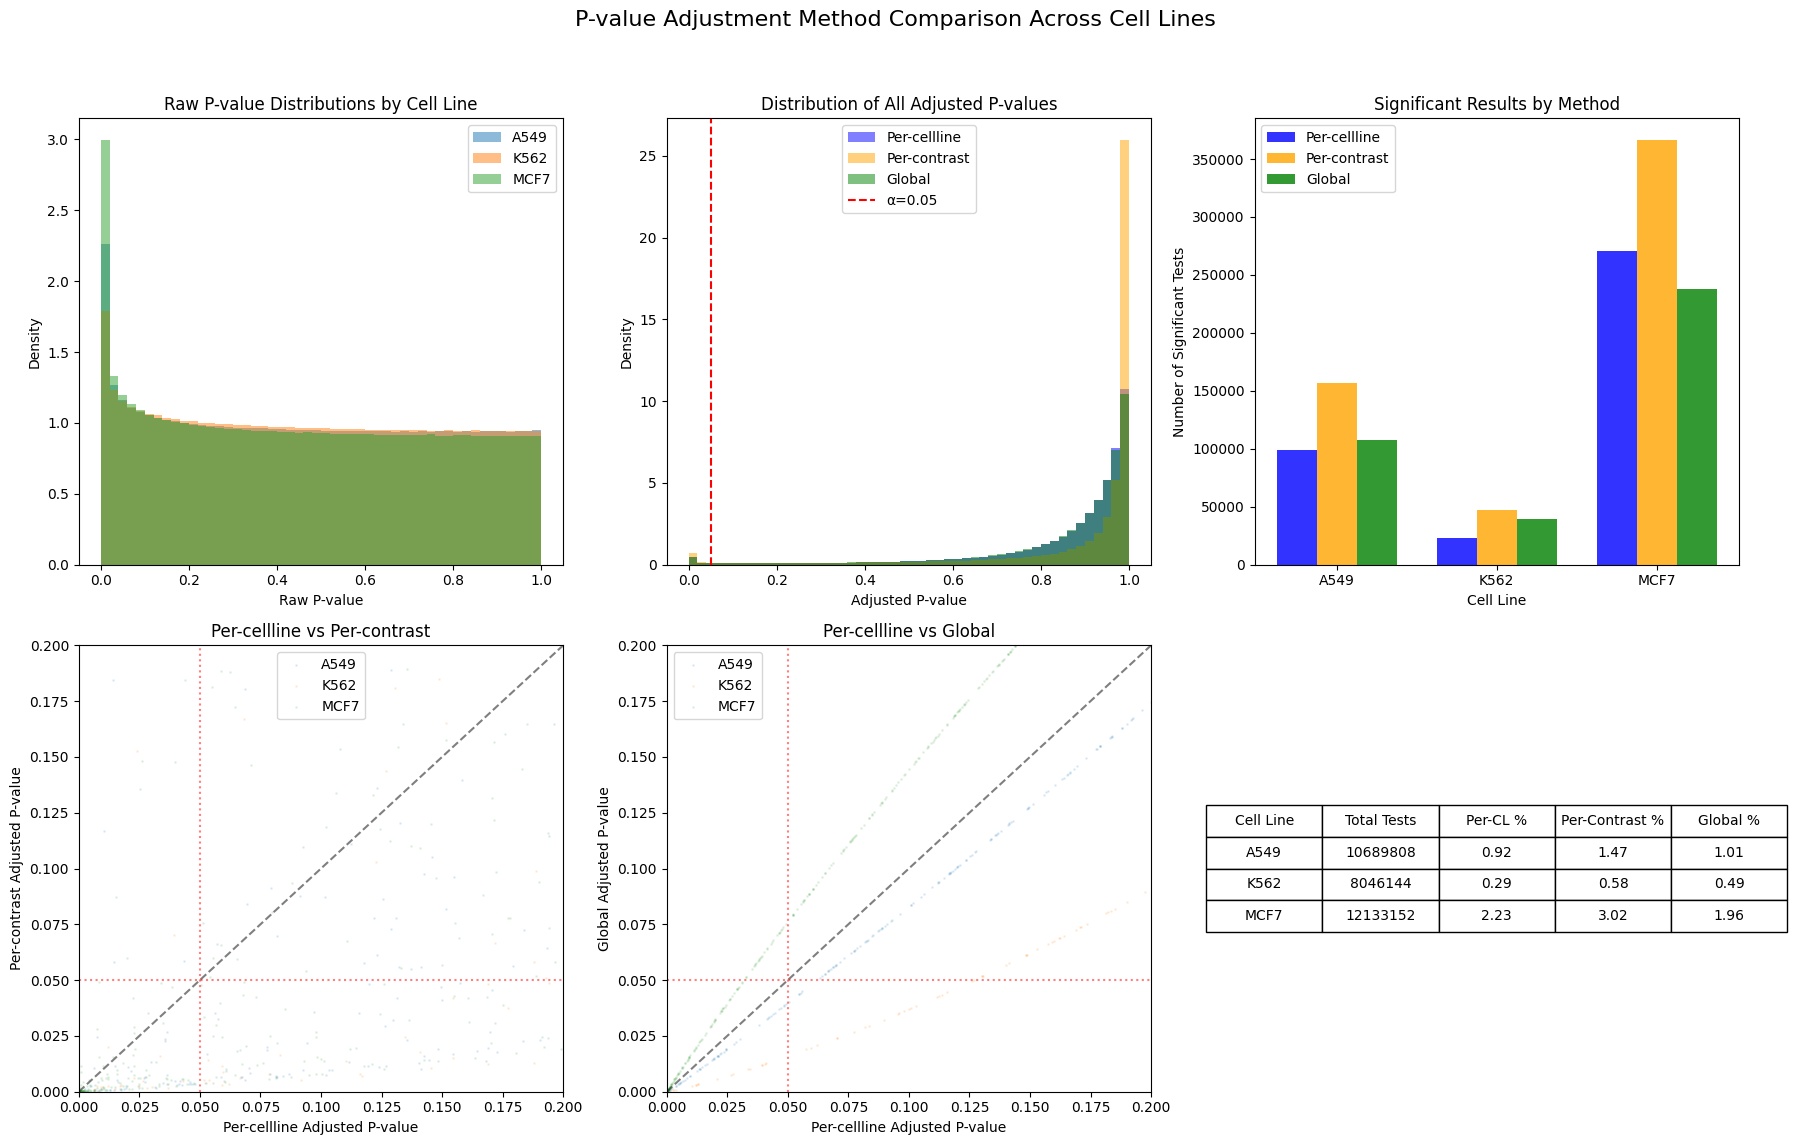


Creating detailed method comparison...


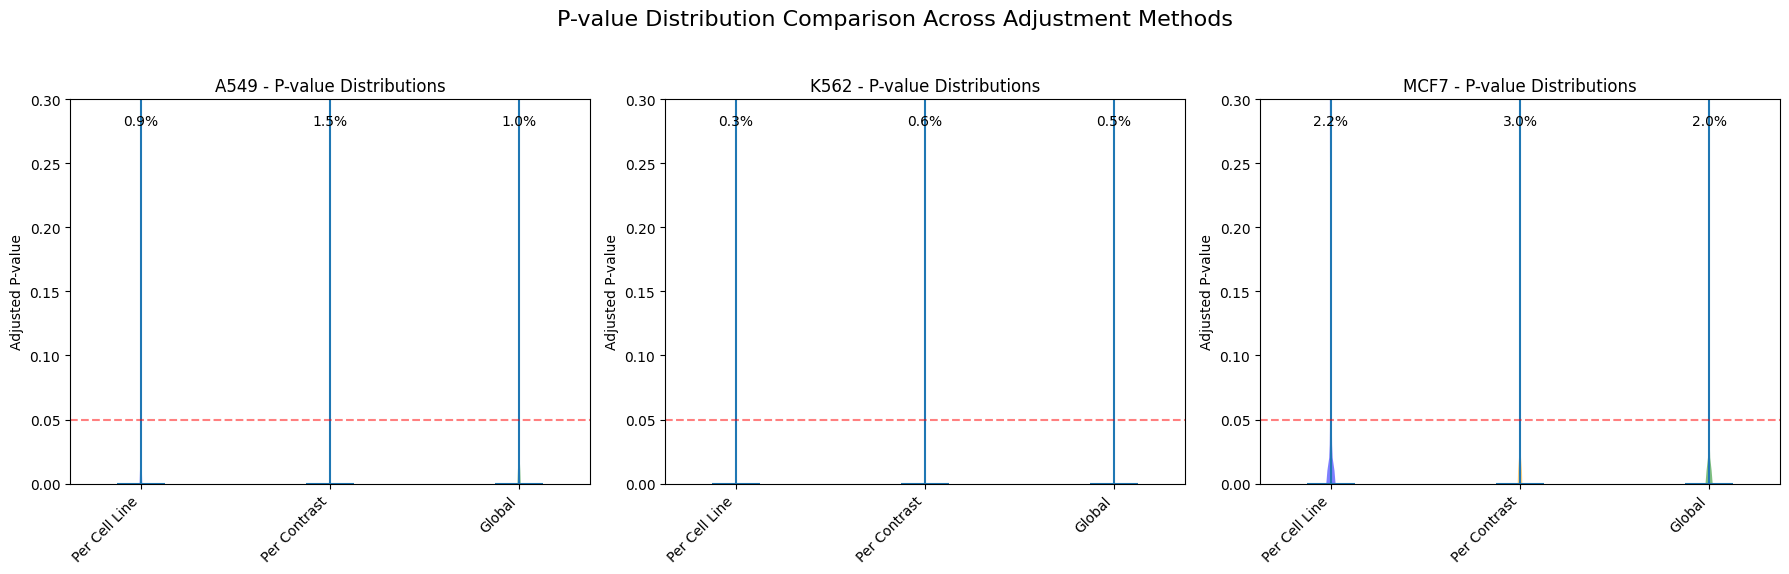


Saving results with all adjustment methods...
  Saved A549 to ../../data/processed/sciplex/deg/A549_de_all_adjustments.h5ad
  Saved K562 to ../../data/processed/sciplex/deg/K562_de_all_adjustments.h5ad
  Saved MCF7 to ../../data/processed/sciplex/deg/MCF7_de_all_adjustments.h5ad

DETAILED STATISTICS REPORT

Overall Statistics:
  Total tests across all cell lines: 30,869,104
  Significant (per-cellline): 392,853 (1.27%)
  Significant (per-contrast): 570,544 (1.85%)
  Significant (global): 385,720 (1.25%)

GENES WITH DRAMATIC CHANGES BETWEEN METHODS

Genes present in all cell lines: 9365

Example genes showing method differences:
       gene  A549_pcl  A549_pc  A549_glob  K562_pcl  K562_pc  K562_glob  \
0  TBC1D10A         0        3          0         2        2          2   
1     NCOA3        38       51         40         2        4          3   
2    WDR45B         3        5          4         1        1          1   
3    ZCCHC7        11       19         13         1        2   

In [19]:
import anndata as ad
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def load_and_prepare_cell_line(cell_line, base_path="../../data/processed/sciplex/deg/"):
    """Load DE results for a cell line and prepare layers."""
    filepath = f"{base_path}{cell_line}_de.h5ad"
    print(f"Loading {cell_line} from {filepath}")
    
    adata = ad.read_h5ad(filepath)
    
    # Rename the original adjusted p-values (assumed BH across all tests in this cell line)
    if 'adj.P.Value' in adata.layers:
        adata.layers['per_cellline_adj.P.Value'] = adata.layers['adj.P.Value']
        del adata.layers['adj.P.Value']
    
    # Add cell line info if not present
    if 'cell_line' not in adata.obs.columns:
        adata.obs['cell_line'] = cell_line
    
    print(f"  Shape: {adata.shape[0]} contrasts × {adata.shape[1]} genes")
    return adata


def adjust_pvalues_per_contrast(adata):
    """
    Adjust p-values separately for each contrast (i.e., each row) via BH,
    without grouping—assumes each obs row is already one unique contrast.
    """
    # Extract raw p-values matrix
    pvals = adata.layers['P.Value']  # shape (n_contrasts, n_genes)
    n_contrasts, n_genes = pvals.shape
    
    # Prepare output array
    adj_pvals = np.full_like(pvals, np.nan)
    
    print(f"  Adjusting p-values for {n_contrasts} contrasts (row-by-row) ...")
    for i in range(n_contrasts):
        row = pvals[i, :]
        valid = ~np.isnan(row)
        if valid.sum() > 0:
            _, row_adj, _, _ = multipletests(row[valid], method='fdr_bh')
            adj_pvals[i, valid] = row_adj
    
    adata.layers['per_contrast_adj.P.Value'] = adj_pvals
    
    # Report statistics per contrast
    n_sig_per_contrast = np.sum(adj_pvals < 0.05, axis=1)
    print(f"    Median significant genes per contrast: {np.median(n_sig_per_contrast):.0f}")
    print(f"    Range: {np.min(n_sig_per_contrast)}–{np.max(n_sig_per_contrast)}")
    return adata


def adjust_pvalues_globally_multiline(adata_dict):
    """
    Adjust p-values globally across all cell lines in adata_dict.
    This version flattens each cell line's p-values to 1D, collects all valid entries,
    runs BH once, then redistributes the adjusted p-values back to each AnnData.
    """
    # Step 1: Collect all valid p-values from every cell line
    all_valid_pvals = []
    counts_per_cl = {}  # how many valid p-values per cell line
    for cl, adata in adata_dict.items():
        flat = adata.layers['P.Value'].flatten()
        valid_mask = ~np.isnan(flat)
        valid_pvals = flat[valid_mask]
        counts_per_cl[cl] = valid_pvals.size
        all_valid_pvals.append(valid_pvals)
    
    # Concatenate into one big 1D array
    concatenated = np.concatenate(all_valid_pvals)
    total_tests = concatenated.size
    print(f"\nTotal non-NaN p-values to adjust globally: {total_tests:,}")
    
    # Step 2: Run BH on the combined array
    print("Performing global FDR adjustment ...")
    _, all_adj_flat, _, _ = multipletests(concatenated, method='fdr_bh')
    
    # Step 3: Redistribute the adjusted values back to each cell line
    print("\nDistributing global-adjusted p-values back to cell lines ...")
    start = 0
    for cl, adata in adata_dict.items():
        n_valid = counts_per_cl[cl]
        end = start + n_valid
        adj_slice = all_adj_flat[start:end]
        start = end
        
        # Now put adj_slice back into a new array of the same shape as P.Value
        flat = adata.layers['P.Value'].flatten()
        valid_mask = ~np.isnan(flat)
        full_adj_flat = np.full(flat.shape, np.nan)
        full_adj_flat[valid_mask] = adj_slice
        reshaped_adj = full_adj_flat.reshape(adata.layers['P.Value'].shape)
        
        adata.layers['global_adj.P.Value'] = reshaped_adj
        
        # Report per-cell-line stats
        mask2 = ~np.isnan(reshaped_adj)
        n_total = np.sum(mask2)
        n_sig = np.sum(reshaped_adj[mask2] < 0.05)
        pct = (n_sig / n_total * 100) if n_total > 0 else 0.0
        print(f"  {cl}: {n_sig:,} / {n_total:,} significant ({pct:.1f}%)")
    
    # Overall global summary
    total_sig = np.sum(all_adj_flat < 0.05)
    overall_pct = total_sig / total_tests * 100 if total_tests > 0 else 0.0
    print(f"\nGlobal results: {total_sig:,} / {total_tests:,} significant ({overall_pct:.1f}%)")
    
    return adata_dict


def compare_adjustments_across_lines(adata_dict):
    """Compare the three adjustment methods across cell lines."""
    results = []
    for cl, adata in adata_dict.items():
        pcl = adata.layers['per_cellline_adj.P.Value']
        pc = adata.layers['per_contrast_adj.P.Value']
        glob = adata.layers['global_adj.P.Value']
        raw = adata.layers['P.Value']
        
        # Count total tests (non-NaN raw p-values)
        n_tests = np.sum(~np.isnan(raw))
        
        # Count significant tests for each method
        pcl_sig = np.sum((pcl < 0.05) & (~np.isnan(pcl)))
        pc_sig  = np.sum((pc  < 0.05) & (~np.isnan(pc)))
        glob_sig= np.sum((glob < 0.05) & (~np.isnan(glob)))
        
        # Gains/losses relative to per-cell-line
        gained = np.sum((glob < 0.05) & ((pcl >= 0.05) | np.isnan(pcl)))
        lost   = np.sum((glob >= 0.05) & (pcl < 0.05))
        
        # Percent changes (guard division by zero)
        pct_change_global = ((glob_sig - pcl_sig) / pcl_sig * 100) if pcl_sig > 0 else np.nan
        pct_change_contrast = ((pc_sig - pcl_sig) / pcl_sig * 100) if pcl_sig > 0 else np.nan
        
        results.append({
            'cell_line': cl,
            'n_tests': n_tests,
            'per_cellline_sig': pcl_sig,
            'per_contrast_sig': pc_sig,
            'global_sig': glob_sig,
            'gained_with_global': gained,
            'lost_with_global': lost,
            'pct_change_global': pct_change_global,
            'pct_change_contrast': pct_change_contrast
        })
    
    comparison_df = pd.DataFrame(results)
    return comparison_df


def plot_adjustment_comparison(adata_dict):
    """Create visual comparison of p-value adjustment methods."""
    comparison_df = compare_adjustments_across_lines(adata_dict)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    colors = {'per_cellline': 'blue', 'per_contrast': 'orange', 'global': 'green'}
    
    # 1. Raw P-value distributions by cell line
    ax = axes[0, 0]
    for cl, adata in adata_dict.items():
        raw = adata.layers['P.Value'].flatten()
        raw = raw[~np.isnan(raw)]
        ax.hist(raw, bins=50, alpha=0.5, label=cl, density=True)
    ax.set_xlabel('Raw P-value')
    ax.set_ylabel('Density')
    ax.set_title('Raw P-value Distributions by Cell Line')
    ax.legend()
    
    # 2. Combined adjusted p-value distributions
    ax = axes[0, 1]
    for method, key, color in [
        ('Per-cellline', 'per_cellline_adj.P.Value', colors['per_cellline']),
        ('Per-contrast', 'per_contrast_adj.P.Value', colors['per_contrast']),
        ('Global', 'global_adj.P.Value', colors['global'])
    ]:
        all_adj = []
        for adata in adata_dict.values():
            arr = adata.layers[key].flatten()
            all_adj.extend(arr[~np.isnan(arr)])
        ax.hist(all_adj, bins=50, alpha=0.5, label=method, density=True, color=color)
    ax.axvline(0.05, color='red', linestyle='--', label='α=0.05')
    ax.set_xlabel('Adjusted P-value')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of All Adjusted P-values')
    ax.legend()
    
    # 3. Bar chart: number of significant tests per method
    ax = axes[0, 2]
    x = np.arange(len(comparison_df))
    width = 0.25
    ax.bar(x - width, comparison_df['per_cellline_sig'], width,
           label='Per-cellline', color=colors['per_cellline'], alpha=0.8)
    ax.bar(x,      comparison_df['per_contrast_sig'], width,
           label='Per-contrast', color=colors['per_contrast'], alpha=0.8)
    ax.bar(x + width, comparison_df['global_sig'], width,
           label='Global', color=colors['global'], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['cell_line'])
    ax.set_xlabel('Cell Line')
    ax.set_ylabel('Number of Significant Tests')
    ax.set_title('Significant Results by Method')
    ax.legend()
    
    # 4. Scatter: Per-cellline vs Per-contrast
    ax = axes[1, 0]
    for cl, adata in adata_dict.items():
        pcl = adata.layers['per_cellline_adj.P.Value'].flatten()
        pc  = adata.layers['per_contrast_adj.P.Value'].flatten()
        mask = ~np.isnan(pcl) & ~np.isnan(pc)
        pcl_vals = pcl[mask]
        pc_vals  = pc[mask]
        if pcl_vals.size > 10000:
            idx = np.random.choice(pcl_vals.size, 10000, replace=False)
            pcl_vals = pcl_vals[idx]
            pc_vals  = pc_vals[idx]
        ax.scatter(pcl_vals, pc_vals, s=1, alpha=0.1, label=cl)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.axvline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.axhline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Per-cellline Adjusted P-value')
    ax.set_ylabel('Per-contrast Adjusted P-value')
    ax.set_title('Per-cellline vs Per-contrast')
    ax.set_xlim(0, 0.2)
    ax.set_ylim(0, 0.2)
    ax.legend()
    
    # 5. Scatter: Per-cellline vs Global
    ax = axes[1, 1]
    for cl, adata in adata_dict.items():
        pcl  = adata.layers['per_cellline_adj.P.Value'].flatten()
        glob = adata.layers['global_adj.P.Value'].flatten()
        mask = ~np.isnan(pcl) & ~np.isnan(glob)
        pcl_vals  = pcl[mask]
        glob_vals = glob[mask]
        if pcl_vals.size > 10000:
            idx = np.random.choice(pcl_vals.size, 10000, replace=False)
            pcl_vals  = pcl_vals[idx]
            glob_vals = glob_vals[idx]
        ax.scatter(pcl_vals, glob_vals, s=1, alpha=0.1, label=cl)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.axvline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.axhline(0.05, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Per-cellline Adjusted P-value')
    ax.set_ylabel('Global Adjusted P-value')
    ax.set_title('Per-cellline vs Global')
    ax.set_xlim(0, 0.2)
    ax.set_ylim(0, 0.2)
    ax.legend()
    
    # 6. Summary table
    ax = axes[1, 2]
    ax.axis('off')
    summary = comparison_df.copy()
    summary['%_cellline'] = (summary['per_cellline_sig'] / summary['n_tests'] * 100).round(2)
    summary['%_contrast']  = (summary['per_contrast_sig'] / summary['n_tests'] * 100).round(2)
    summary['%_global']    = (summary['global_sig'] / summary['n_tests'] * 100).round(2)
    table_data = summary[['cell_line', 'n_tests', '%_cellline', '%_contrast', '%_global']].values
    table = ax.table(
        cellText=table_data,
        colLabels=['Cell Line', 'Total Tests', 'Per-CL %', 'Per-Contrast %', 'Global %'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    plt.suptitle('P-value Adjustment Method Comparison Across Cell Lines', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig, comparison_df


# Main execution
if __name__ == "__main__":
    # Define cell lines to process
    cell_lines = ['A549', 'K562', 'MCF7']
    
    # Load all cell lines
    print("Loading DE results for all cell lines...")
    adata_dict = {}
    for cl in cell_lines:
        try:
            adata = load_and_prepare_cell_line(cl)
            print(f"  Applying per-contrast adjustment for {cl}...")
            adata = adjust_pvalues_per_contrast(adata)
            adata_dict[cl] = adata
        except FileNotFoundError:
            print(f"  Warning: Could not find file for {cl}")
            continue
    print(f"\nSuccessfully loaded {len(adata_dict)} cell lines")
    
    # Apply global adjustment
    print("\n" + "="*60)
    print("APPLYING GLOBAL ADJUSTMENT ACROSS ALL CELL LINES")
    print("="*60)
    adata_dict = adjust_pvalues_globally_multiline(adata_dict)
    
    # Compare results
    print("\n" + "="*60)
    print("COMPARISON OF ADJUSTMENT METHODS")
    print("="*60)
    comparison_df = compare_adjustments_across_lines(adata_dict)
    print("\n", comparison_df.to_string(index=False))
    
    # Create visualizations
    print("\nCreating visualizations...")
    fig, _ = plot_adjustment_comparison(adata_dict)
    fig.savefig('adjustment_comparison_all_methods.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Detailed violin plots per cell line
    print("\nCreating detailed method comparison...")
    fig2, axes2 = plt.subplots(1, len(adata_dict), figsize=(6 * len(adata_dict), 6))
    for idx, (cl, adata) in enumerate(adata_dict.items()):
        ax = axes2[idx] if len(adata_dict) > 1 else axes2
        methods_data = []
        labels = []
        for label, layer_key in [
            ('Per Cell Line', 'per_cellline_adj.P.Value'),
            ('Per Contrast', 'per_contrast_adj.P.Value'),
            ('Global', 'global_adj.P.Value')
        ]:
            vals = adata.layers[layer_key].flatten()
            vals = vals[~np.isnan(vals)]
            methods_data.append(vals)
            labels.append(label)
        parts = ax.violinplot(methods_data, positions=range(len(methods_data)),
                              showmeans=True, showmedians=True)
        colors_v = ['blue', 'orange', 'green']
        for body, color in zip(parts['bodies'], colors_v):
            body.set_facecolor(color)
            body.set_alpha(0.5)
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylabel('Adjusted P-value')
        ax.set_ylim(0, 0.3)
        ax.set_title(f'{cl} - P-value Distributions')
        # Annotate percent significant
        for i, data in enumerate(methods_data):
            n_sig = np.sum(data < 0.05)
            pct_sig = n_sig / data.size * 100 if data.size > 0 else 0
            ax.text(i, 0.28, f'{pct_sig:.1f}%', ha='center', fontsize=10)
    plt.suptitle('P-value Distribution Comparison Across Adjustment Methods', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig2.savefig('pvalue_distributions_by_method.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save updated AnnData objects
    print("\nSaving results with all adjustment methods...")
    for cl, adata in adata_dict.items():
        out_path = f"../../data/processed/sciplex/deg/{cl}_de_all_adjustments.h5ad"
        adata.write_h5ad(out_path, compression='gzip')
        print(f"  Saved {cl} to {out_path}")
    
    # Detailed statistics report
    print("\n" + "="*60)
    print("DETAILED STATISTICS REPORT")
    print("="*60)
    total_tests = comparison_df['n_tests'].sum()
    total_pcl  = comparison_df['per_cellline_sig'].sum()
    total_pc   = comparison_df['per_contrast_sig'].sum()
    total_glob = comparison_df['global_sig'].sum()
    print(f"\nOverall Statistics:")
    print(f"  Total tests across all cell lines: {total_tests:,}")
    print(f"  Significant (per-cellline): {total_pcl:,} ({total_pcl/total_tests*100:.2f}%)")
    print(f"  Significant (per-contrast): {total_pc:,} ({total_pc/total_tests*100:.2f}%)")
    print(f"  Significant (global): {total_glob:,} ({total_glob/total_tests*100:.2f}%)")
    
    # Example genes with method differences
    print("\n" + "="*60)
    print("GENES WITH DRAMATIC CHANGES BETWEEN METHODS")
    print("="*60)
    common_genes = None
    for adata in adata_dict.values():
        genes = set(adata.var.index)
        common_genes = genes if common_genes is None else common_genes.intersection(genes)
    print(f"\nGenes present in all cell lines: {len(common_genes)}")
    
    if common_genes:
        gene_analysis = []
        for gene in list(common_genes)[:10]:
            row = {'gene': gene}
            for cl, adata in adata_dict.items():
                gi = list(adata.var.index).index(gene)
                row[f'{cl}_pcl']  = np.sum(adata.layers['per_cellline_adj.P.Value'][:, gi] < 0.05)
                row[f'{cl}_pc']   = np.sum(adata.layers['per_contrast_adj.P.Value'][:, gi] < 0.05)
                row[f'{cl}_glob'] = np.sum(adata.layers['global_adj.P.Value'][:, gi] < 0.05)
            gene_analysis.append(row)
        gene_df = pd.DataFrame(gene_analysis)
        print("\nExample genes showing method differences:")
        print(gene_df.head())
    
    print("\nAnalysis complete!")